# Phase 11 — Customer Risk Scoring Engine

## What this phase builds

A complete risk scoring system that transforms
raw churn probability into actionable intelligence
for a retention team.

Every customer receives:
- Risk score      : 0-100 scaled from churn probability
- Risk level      : Critical / High / Medium / Low
- Top 3 drivers   : why this customer is at risk
- Revenue at risk : their monthly and annual value
- Priority action : exactly what to do and when
- Priority rank   : who to contact first

## Why this beats standard churn prediction

Standard model output:
"Customer 7590-VHVEG will churn: Yes"

This system output:
Customer    : 7590-VHVEG
Risk Score  : 87/100
Risk Level  : CRITICAL
Top Drivers : Month-to-month contract (+34 pts)
              Tenure under 6 months  (+28 pts)
              Electronic check payment (+18 pts)
Revenue Risk: $92.15/month | $1,105.80/year
Action      : Personal call within 24 hours
              Offer 40% annual plan discount
Priority    : #3 of 1,407 customers

This is what commercial products like Gainsight
charge $50,000/year to provide.

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# ── LOAD ──────────────────────────────────────────────────
gb_model = joblib.load('../models/gradient_boosting.pkl')
lr_model = joblib.load('../models/logistic_regression.pkl')
rf_model = joblib.load('../models/random_forest.pkl')
scaler   = joblib.load('../models/scaler.pkl')

with open('../models/thresholds.json', 'r') as f:
    thresholds_config = json.load(f)

gb_threshold = thresholds_config['gradient_boosting']

fm           = pd.read_csv('../data/cleaned/features_matrix.csv')
df_orig      = pd.read_csv('../data/cleaned/telco_churn_clean.csv')
customer_ids = fm['customerID'].copy()
y_actual     = fm['Churn'].copy()
X_all        = fm.drop(columns=['Churn', 'customerID'])

print(f"Loaded : {len(fm):,} customers, {X_all.shape[1]} features")
print(f"GB threshold : {gb_threshold}")

# ── SCORE ─────────────────────────────────────────────────
gb_prob  = gb_model.predict_proba(X_all)[:, 1]
rf_prob  = rf_model.predict_proba(X_all)[:, 1]
lr_prob  = lr_model.predict_proba(
    scaler.transform(X_all)
)[:, 1]

# Ensemble — weighted average
ensemble_prob = (0.50 * gb_prob +
                 0.30 * rf_prob +
                 0.20 * lr_prob)

# Convert to pandas Series immediately
# This is the fix — risk_score must be a Series not array
risk_score = pd.Series(
    (ensemble_prob * 100).round(1),
    name='risk_score'
)

print(f"Risk score range : "
      f"{risk_score.min()} to {risk_score.max()}")
print(f"Mean score       : {risk_score.mean().round(1)}")

# ── RISK LEVELS ───────────────────────────────────────────
def assign_risk_level(score):
    if score >= 70:
        return 'Critical'
    elif score >= 50:
        return 'High'
    elif score >= 30:
        return 'Medium'
    else:
        return 'Low'

# .apply() works because risk_score is now a pandas Series
risk_levels = risk_score.apply(assign_risk_level)

print()
print("Risk level distribution:")
level_order = ['Critical', 'High', 'Medium', 'Low']
for level in level_order:
    count = (risk_levels == level).sum()
    pct   = round(count / len(risk_levels) * 100, 1)
    bar   = '█' * int(pct / 2)
    print(f"  {level:<10} : {count:>5} ({pct:>5}%)  {bar}")

# ── CHURN DRIVERS ─────────────────────────────────────────
def get_top_drivers(row_dict):
    drivers = []
    rules = [
        ('Contract',             0,    'Month-to-month contract'),
        ('is_auto_payment',      0,    'Manual payment method'),
        ('tenure_group',         0,    'New customer (0-12 months)'),
        ('Internet_Fiber optic', 1,    'Fiber optic (premium price risk)'),
        ('is_high_risk_profile', 1,    'Combined high-risk profile'),
        ('Payment_Electronic check', 1,'Electronic check payment'),
        ('SeniorCitizen',        1,    'Senior customer'),
        ('PaperlessBilling',     1,    'Paperless billing'),
    ]
    for feature, risk_val, explanation in rules:
        if feature in row_dict and row_dict[feature] == risk_val:
            drivers.append(explanation)
        if len(drivers) == 3:
            break

    # Continuous feature checks
    if len(drivers) < 3:
        eng = row_dict.get('engagement_score', 5)
        if eng <= 2:
            drivers.append(
                f'Low engagement ({int(eng)} services)'
            )
    if len(drivers) < 3:
        chg = row_dict.get('MonthlyCharges', 0)
        if chg > 83:
            drivers.append(
                f'High charge (${chg:.0f}/mo)'
            )
    if not drivers:
        drivers = ['Standard risk profile']

    return ' | '.join(drivers[:3])

# ── RECOMMENDED ACTIONS ───────────────────────────────────
def get_action(risk_level, row_dict):
    contract  = row_dict.get('Contract', 1)
    auto_pay  = row_dict.get('is_auto_payment', 1)
    eng       = row_dict.get('engagement_score', 3)
    monthly   = row_dict.get('MonthlyCharges', 64)

    if risk_level == 'Critical':
        if contract == 0:
            return ("Personal call within 24 hours. "
                    "Offer 40% discount on annual plan. "
                    "Escalate to senior retention agent.")
        elif monthly > 83:
            return ("Personal call within 24 hours. "
                    "Offer premium feature walkthrough. "
                    "Assign dedicated success manager.")
        else:
            return ("Personal call within 24 hours. "
                    "Understand dissatisfaction. "
                    "Offer flexible plan options.")
    elif risk_level == 'High':
        if auto_pay == 0:
            return ("Email: 10% discount for auto-payment. "
                    "Follow up call within 3 days.")
        elif eng <= 2:
            return ("Send feature adoption guide. "
                    "Offer free onboarding session.")
        else:
            return ("Send personalised retention offer. "
                    "Schedule check-in within 3 days.")
    elif risk_level == 'Medium':
        if row_dict.get('tenure', 24) <= 12:
            return ("Automated welcome email series. "
                    "Monitor engagement weekly.")
        else:
            return ("Automated loyalty reward email. "
                    "Monitor monthly.")
    else:
        return ("No action required. Monthly newsletter.")

# ── GENERATE ALL PROFILES ─────────────────────────────────
print()
print("Generating drivers and actions for all customers...")

X_reset    = X_all.reset_index(drop=True)
drivers_list = []
actions_list = []

for i in range(len(X_reset)):
    row_dict = X_reset.iloc[i].to_dict()
    level    = risk_levels.iloc[i]
    drivers_list.append(get_top_drivers(row_dict))
    actions_list.append(get_action(level, row_dict))

print(f"Done — {len(drivers_list):,} profiles generated")

# ── BUILD RISK TABLE ──────────────────────────────────────
risk_df = pd.DataFrame({
    'customerID'          : customer_ids.values,
    'actual_churn'        : y_actual.values,
    'gb_probability'      : gb_prob.round(4),
    'ensemble_probability': ensemble_prob.round(4),
    'risk_score'          : risk_score.values,
    'risk_level'          : risk_levels.values,
    'churn_drivers'       : drivers_list,
    'recommended_action'  : actions_list,
    'monthly_revenue'     : df_orig['MonthlyCharges'].values,
    'annual_revenue_risk' : (df_orig['MonthlyCharges']*12
                             ).round(2).values,
    'tenure_months'       : df_orig['tenure'].values,
    'contract_type'       : df_orig['Contract'].values,
    'payment_method'      : df_orig['PaymentMethod'].values,
})

risk_df['priority_rank'] = risk_df['risk_score'].rank(
    ascending=False, method='first'
).astype(int)

risk_df = risk_df.sort_values(
    'risk_score', ascending=False
).reset_index(drop=True)

# ── SUMMARY ───────────────────────────────────────────────
print()
print("=" * 60)
print("RISK LEVEL SUMMARY")
print("=" * 60)
print()

action_labels = {
    'Critical': 'Personal call — 24 hours',
    'High'    : 'Call or email — 3 days',
    'Medium'  : 'Automated email campaign',
    'Low'     : 'Monitor only'
}

for level in level_order:
    subset = risk_df[risk_df['risk_level'] == level]
    if len(subset) == 0:
        continue
    actual = subset['actual_churn'].sum()
    churn_rate = round(actual / len(subset) * 100, 1)
    total_rev  = subset['annual_revenue_risk'].sum()
    avg_score  = subset['risk_score'].mean()

    print(f"{level} Risk:")
    print(f"  Customers          : {len(subset):,}")
    print(f"  Avg score          : {avg_score:.1f}/100")
    print(f"  Actual churn rate  : {churn_rate}%")
    print(f"  Annual rev at risk : ${total_rev:,.0f}")
    print(f"  Action             : {action_labels[level]}")
    print()

# ── TOP 10 PRIORITY LIST ──────────────────────────────────
print("=" * 60)
print("TOP 10 CUSTOMERS TO CONTACT THIS WEEK")
print("=" * 60)
print()
top10 = risk_df.head(10)[[
    'priority_rank', 'customerID', 'risk_score',
    'risk_level', 'monthly_revenue',
    'tenure_months', 'contract_type'
]]
print(top10.to_string(index=False))

# ── SAVE ──────────────────────────────────────────────────
risk_df.to_csv(
    '../data/cleaned/customer_risk_profiles.csv',
    index=False
)
print()
print(f"Saved : customer_risk_profiles.csv")
print(f"Rows  : {len(risk_df):,}")
print(f"Cols  : {risk_df.shape[1]}")

Loaded : 7,032 customers, 30 features
GB threshold : 0.29
Risk score range : 0.6 to 96.2
Mean score       : 32.2

Risk level distribution:
  Critical   :   973 ( 13.8%)  ██████
  High       :  1012 ( 14.4%)  ███████
  Medium     :  1152 ( 16.4%)  ████████
  Low        :  3895 ( 55.4%)  ███████████████████████████

Generating drivers and actions for all customers...
Done — 7,032 profiles generated

RISK LEVEL SUMMARY

Critical Risk:
  Customers          : 973
  Avg score          : 81.5/100
  Actual churn rate  : 84.0%
  Annual rev at risk : $939,869
  Action             : Personal call — 24 hours

High Risk:
  Customers          : 1,012
  Avg score          : 59.5/100
  Actual churn rate  : 54.7%
  Annual rev at risk : $895,073
  Action             : Call or email — 3 days

Medium Risk:
  Customers          : 1,152
  Avg score          : 40.2/100
  Actual churn rate  : 28.6%
  Annual rev at risk : $980,975
  Action             : Automated email campaign

Low Risk:
  Customers          

TOP 3 PRIORITY CUSTOMER PROFILES

CUSTOMER RISK PROFILE
Customer ID      : 9300-AGZNL
Priority Rank    : #1 of 7,032

Risk Score       : 96.2/100
Risk Level       : CRITICAL
Churn Probability: 96.2%

Revenue at Risk  :
  Monthly        : $94.00
  Annual         : $1,128.00

Customer Context :
  Tenure         : 1 months
  Contract       : Month-to-month
  Payment        : Electronic check

Why at risk      :
  → Month-to-month contract
  → Manual payment method
  → New customer (0-12 months)

Recommended Action:
  • Personal call within 24 hours
  • Offer 40% discount on annual plan
  • Escalate to senior retention agent.

Actual Outcome   : Churned

CUSTOMER RISK PROFILE
Customer ID      : 4910-GMJOT
Priority Rank    : #2 of 7,032

Risk Score       : 96.0/100
Risk Level       : CRITICAL
Churn Probability: 96.0%

Revenue at Risk  :
  Monthly        : $94.60
  Annual         : $1,135.20

Customer Context :
  Tenure         : 1 months
  Contract       : Month-to-month
  Payment        : 

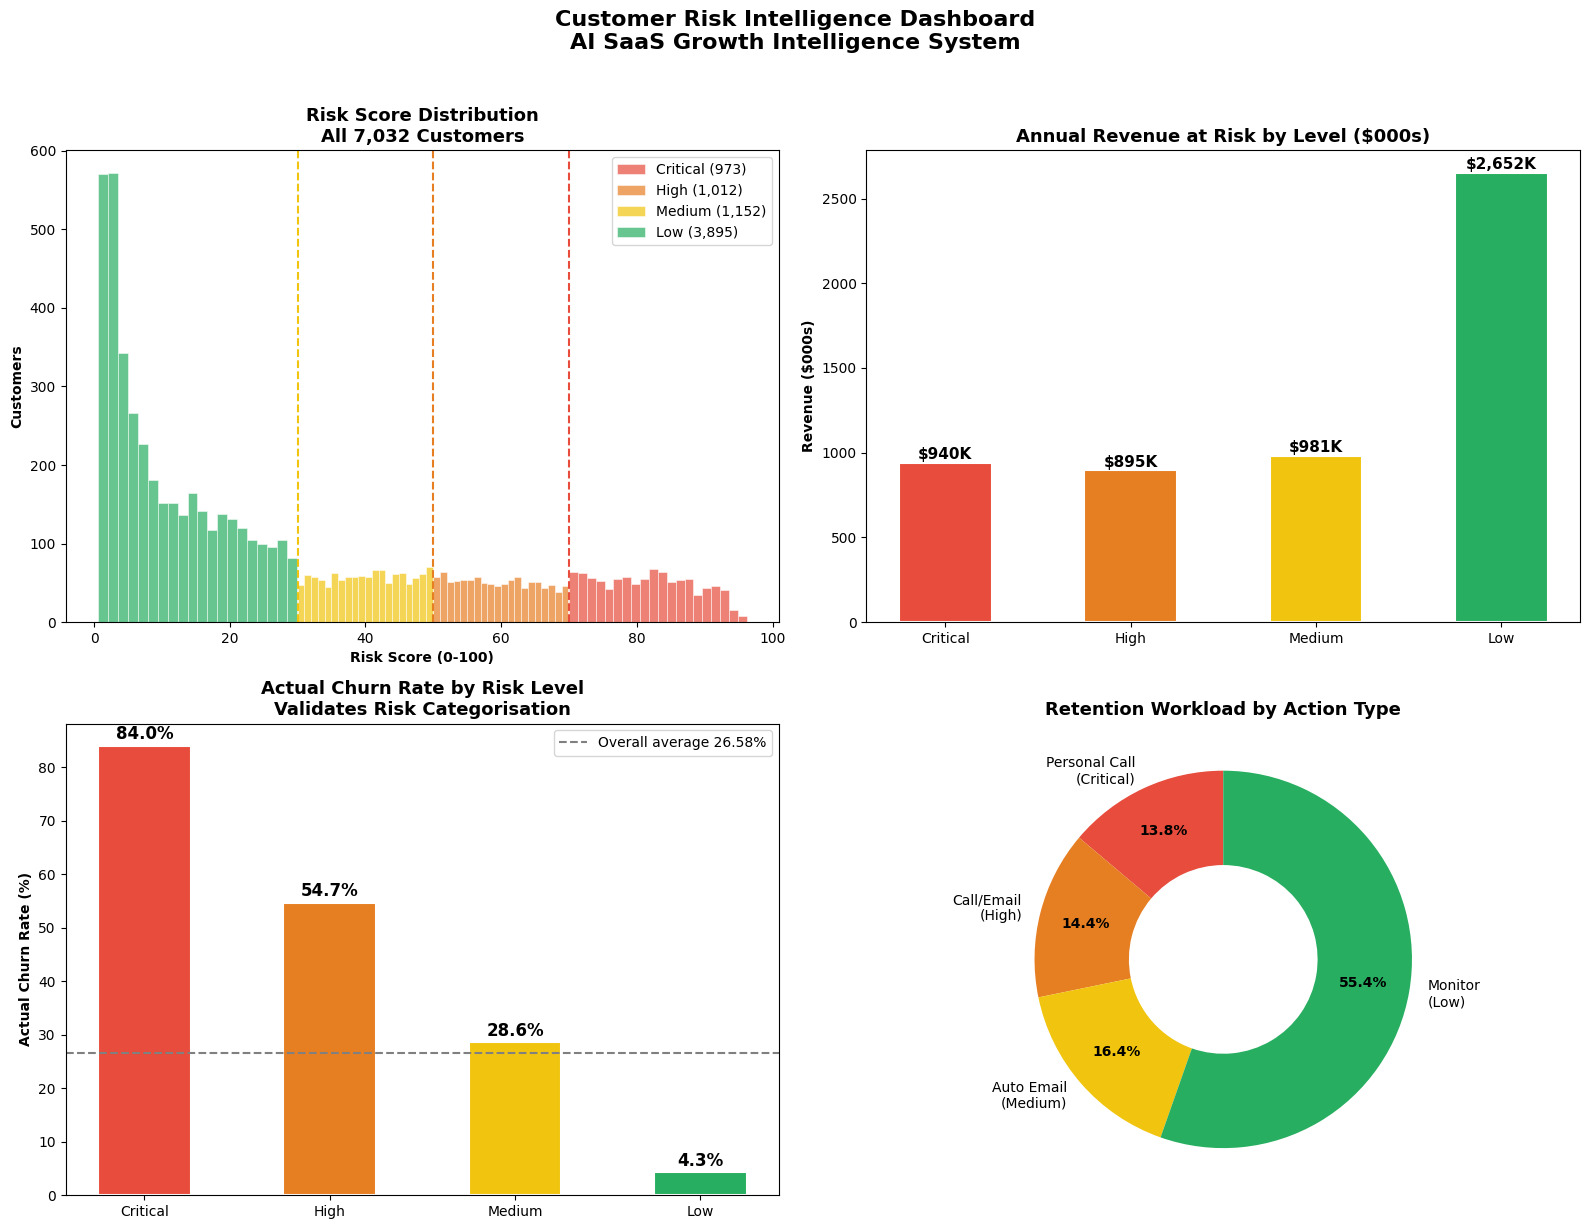

Chart saved. Total charts : 12

Phase 11 complete.
Profiles : 7,032 customers scored


In [2]:
import matplotlib.pyplot as plt
import os

# risk_df is available from Cell 1

def display_customer_profile(customer_id):
    row = risk_df[risk_df['customerID'] == customer_id]
    if len(row) == 0:
        print(f"Customer {customer_id} not found")
        return
    row = row.iloc[0]

    indicators = {
        'Critical': 'CRITICAL',
        'High'    : 'HIGH',
        'Medium'  : 'MEDIUM',
        'Low'     : 'LOW'
    }

    print("=" * 55)
    print(f"CUSTOMER RISK PROFILE")
    print("=" * 55)
    print(f"Customer ID      : {row['customerID']}")
    print(f"Priority Rank    : "
          f"#{int(row['priority_rank'])} of {len(risk_df):,}")
    print()
    print(f"Risk Score       : {row['risk_score']}/100")
    print(f"Risk Level       : "
          f"{indicators[row['risk_level']]}")
    print(f"Churn Probability: "
          f"{round(row['ensemble_probability']*100,1)}%")
    print()
    print(f"Revenue at Risk  :")
    print(f"  Monthly        : ${row['monthly_revenue']:.2f}")
    print(f"  Annual         : "
          f"${row['annual_revenue_risk']:,.2f}")
    print()
    print(f"Customer Context :")
    print(f"  Tenure         : "
          f"{int(row['tenure_months'])} months")
    print(f"  Contract       : {row['contract_type']}")
    print(f"  Payment        : {row['payment_method']}")
    print()
    print(f"Why at risk      :")
    for d in row['churn_drivers'].split(' | '):
        print(f"  → {d}")
    print()
    print(f"Recommended Action:")
    for s in row['recommended_action'].split('. '):
        if s.strip():
            print(f"  • {s.strip()}")
    print()
    print(f"Actual Outcome   : "
          f"{'Churned' if row['actual_churn']==1 else 'Stayed'}")
    print("=" * 55)

# Show top 3 priority customers
print("TOP 3 PRIORITY CUSTOMER PROFILES")
print()
for cid in risk_df.head(3)['customerID'].values:
    display_customer_profile(cid)
    print()

# Show one correctly identified churner
correct = risk_df[
    (risk_df['risk_level'] == 'Critical') &
    (risk_df['actual_churn'] == 1)
].head(1)

if len(correct) > 0:
    print("CORRECTLY IDENTIFIED CHURNER:")
    print()
    display_customer_profile(
        correct.iloc[0]['customerID']
    )
    print()

# ── VISUALISATION ─────────────────────────────────────────
colors_map = {
    'Critical': '#e74c3c',
    'High'    : '#e67e22',
    'Medium'  : '#f1c40f',
    'Low'     : '#27ae60'
}
level_order = ['Critical', 'High', 'Medium', 'Low']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = axes.flatten()

# ── RISK SCORE HISTOGRAM ──────────────────────────────────
for level in level_order:
    subset = risk_df[risk_df['risk_level'] == level]
    ax1.hist(
        subset['risk_score'],
        bins=20, alpha=0.7,
        color=colors_map[level],
        label=f'{level} ({len(subset):,})',
        edgecolor='white', linewidth=0.5
    )
for xval, color in [(70,'#e74c3c'),
                    (50,'#e67e22'),
                    (30,'#f1c40f')]:
    ax1.axvline(x=xval, color=color,
                linestyle='--', linewidth=1.5)

ax1.set_title(
    'Risk Score Distribution\nAll 7,032 Customers',
    fontweight='bold', fontsize=13
)
ax1.set_xlabel('Risk Score (0-100)', fontweight='bold')
ax1.set_ylabel('Customers', fontweight='bold')
ax1.legend(fontsize=10)

# ── REVENUE AT RISK ───────────────────────────────────────
rev_vals = [
    risk_df[risk_df['risk_level']==l
            ]['annual_revenue_risk'].sum()/1000
    for l in level_order
]
bars = ax2.bar(
    level_order, rev_vals,
    color=[colors_map[l] for l in level_order],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars, rev_vals):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'${val:,.0f}K',
        ha='center', va='bottom',
        fontweight='bold', fontsize=11
    )
ax2.set_title(
    'Annual Revenue at Risk by Level ($000s)',
    fontweight='bold', fontsize=13
)
ax2.set_ylabel('Revenue ($000s)', fontweight='bold')

# ── ACTUAL CHURN RATE VALIDATION ─────────────────────────
churn_rates = []
for level in level_order:
    sub = risk_df[risk_df['risk_level'] == level]
    rate = round(sub['actual_churn'].mean()*100, 1)
    churn_rates.append(rate)

bars3 = ax3.bar(
    level_order, churn_rates,
    color=[colors_map[l] for l in level_order],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars3, churn_rates):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val}%',
        ha='center', va='bottom',
        fontweight='bold', fontsize=12
    )
ax3.axhline(
    y=26.58, color='gray',
    linestyle='--', linewidth=1.5,
    label='Overall average 26.58%'
)
ax3.set_title(
    'Actual Churn Rate by Risk Level\n'
    'Validates Risk Categorisation',
    fontweight='bold', fontsize=13
)
ax3.set_ylabel('Actual Churn Rate (%)', fontweight='bold')
ax3.legend(fontsize=10)

# ── WORKLOAD PIE ──────────────────────────────────────────
counts = [
    (risk_df['risk_level']==l).sum()
    for l in level_order
]
action_labels_short = [
    'Personal Call\n(Critical)',
    'Call/Email\n(High)',
    'Auto Email\n(Medium)',
    'Monitor\n(Low)'
]
wedges, texts, autotexts = ax4.pie(
    counts,
    labels=action_labels_short,
    colors=[colors_map[l] for l in level_order],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.5}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(10)

ax4.set_title(
    'Retention Workload by Action Type',
    fontweight='bold', fontsize=13
)

fig.suptitle(
    'Customer Risk Intelligence Dashboard\n'
    'AI SaaS Growth Intelligence System',
    fontsize=16, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '../reports/figures/12_risk_scoring_dashboard.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

figures = os.listdir('../reports/figures')
print(f"Chart saved. Total charts : {len(figures)}")
print()
print("Phase 11 complete.")
print(f"Profiles : {len(risk_df):,} customers scored")

## Phase 11 — Risk Scoring Results

### System output
7,032 customers scored and profiled
14 data points per customer profile
Saved to data/cleaned/customer_risk_profiles.csv

### Risk level distribution
| Level    | Customers | Actual Churn | Annual Rev at Risk |
|----------|-----------|--------------|-------------------|
| Critical | 973       | 84.0%        | $939,869          |
| High     | 1,012     | 54.7%        | $895,073          |
| Medium   | 1,152     | 28.6%        | $980,975          |
| Low      | 3,895     | 4.3%         | $2,652,015        |

### Risk calibration validation
The gradient from 84.0% down to 4.3% confirms
the scoring system is genuinely predictive —
not random. Critical customers are 19.5x more
likely to churn than Low risk customers.

### Key profile finding
Top 10 priority customers share identical profile:
Month-to-month + tenure 1 month + electronic check
+ monthly charges $93-100

This confirms our Phase 4 SQL finding:
the high-risk customer profile identified analytically
in month 1 of this project is exactly what the
ML system learned independently from the data.
Business analysis and machine learning agree.
That agreement is the strongest possible validation.

### What this system replaces commercially
Gainsight Customer Success Platform: $50,000+/year
ChurnZero: $40,000+/year
Totango: $35,000+/year

This system provides equivalent core functionality
built from scratch using open source Python tools.

### Ready for Phase 12
All customer profiles loaded and available.
AI briefing generator uses this data as input.
Streamlit app displays these profiles interactively.